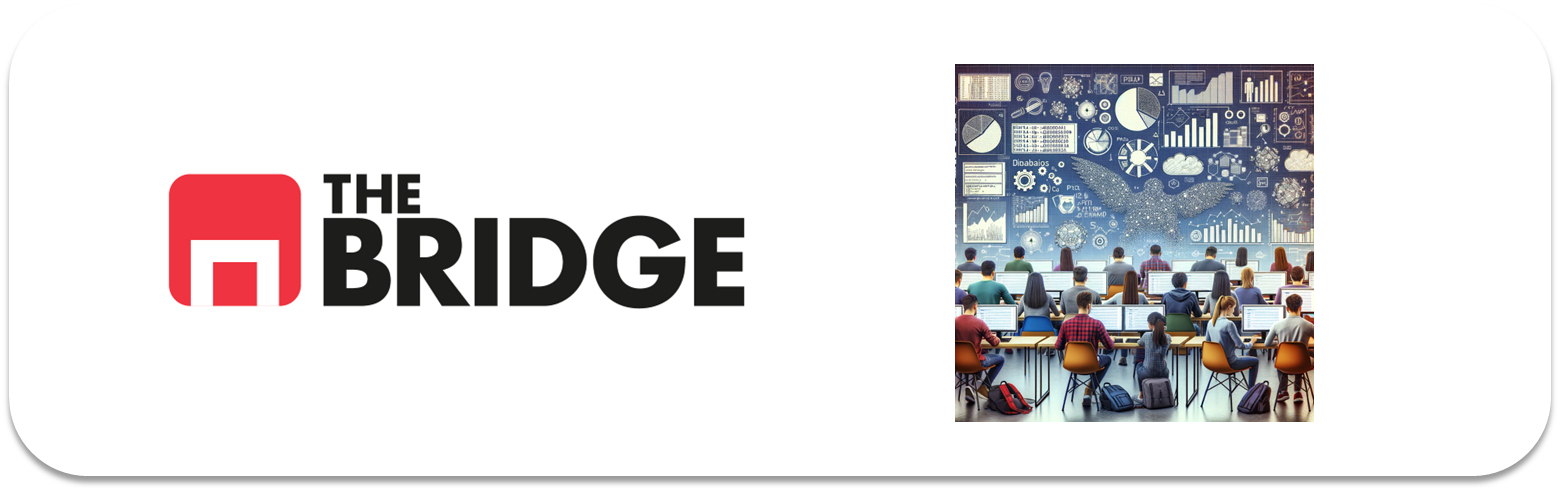

## PRACTICA OBLIGATORIA: **Regresion Lineal y Regularización**

* La práctica obligatoria de esta unidad consiste en hacer un modelado completo de un problema que ya conoces, la predicción de casas, pero con otro dataset. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Modelo de Regresión Lineal

El objetivo del modelo que tienes que construir es predecir la mediana del precio de las casas en una zona del área metropolitana de Boston dadas las características de las mismas. Sí, es parecido pero no igual a lo que hemos venido haciendo.

Aquí tienes una descripción de las variables del dataset, del que tendrás que decidir el target:  

***CRIM:*** Tasa de criminalidad per cápita por ciudad  
***ZN:*** Proporción de terreno residencial destinado a lotes de más de 25,000 pies cuadrados  
***INDUS:*** Proporción de acres de negocios no minoristas por ciudad  
***CHAS:*** Variable ficticia del río Charles (= 1 si el sector limita con el río; 0 en caso contrario)  
***NOX:*** Concentración de óxidos de nitrógeno (partes por 10 millones)  
***RM:*** Número promedio de habitaciones por vivienda  
***AGE:*** Proporción de unidades ocupadas por el propietario construidas antes de 1940  
***DIS:*** Distancias ponderadas a cinco centros de empleo de Boston  
***RAD:*** Índice de accesibilidad a autopistas radiales  
***TAX:*** Tasa de impuesto sobre la propiedad de valor total por $10,000  
***PTRATIO:*** Relación alumno-maestro por ciudad  
***LSTAT:*** % de población de estatus socioeconómico bajo  
***MEDV:*** Valor medio de las viviendas ocupadas por sus propietarios en miles de dólares  

### Indicaciones

A continuación tienes las indicaciones para hacer el modelado. No necesariamente tienes que seguirlos al pie de la letra, porque a partir de ahora ya las práctica obligatorias dejarán de ser mayormente guiadas por ejercicios y serán más de libre desarrollo, aunque con objetivos específicos, claros y determinados. 

En concreto se pide hacer un modelo de regresión lineal, evaluarlo contra un dataset de test reservado del original mostrando MAE,RMSE,MSE y $R2$, comparar las predicciones con los valores reales y realizar al menos un tipo de regularización de las conocidas, testando por lo menos 3 valores diferentes de hiperparámetros.

Los pasos para guiar el trabajo:
1. Carga el dataset. Está limpio y no necesitarás completar nulos, ni repasar los valores de las columnas.
2. Escoge y analiza la variable target de forma gráfica para ver la idoneidad de hacer un modelo de regresión.
3. Haz el split en train y test que creas conveniente y de la forma que creas conveniente.
4. Construye las parejas X,y de train y test
5. Haz un mini-EDA, selecciona las features que quieres quedarte y por qué.
6. Trata las variables para que funcionen lo mejor posible en el modelo.
7. Construye un modelo de regresión lineal.
8. Analiza si lo crees conveniente los pesos y la importancia de las features.
8. Evalúa tu modelo. Haz un pequeño assesmente de su generabilidad. Compara gráficamente las predicciones con los valores reales.
9. Regulariza al menos con un modelo alternativo y juega con 3 posibles valores de los hiperparámetros del modelo de regularización.
10. Expresa tus conclusiones, en concreto ¿con qué modelo te quedarías?¿por qué?



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Carga directa desde un CSV público (mismo dataset Boston original)
url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
df = pd.read_csv(url)

# Renombramos las columnas a mayúsculas para que coincidan con el enunciado
df.columns = df.columns.str.upper()

# El target en este CSV se llama MEDV (ya viene así)
print(df.shape)
print(df.head())
print(df.info())

(506, 14)
      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  PTRATIO  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        B  LSTAT  MEDV  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  
<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64

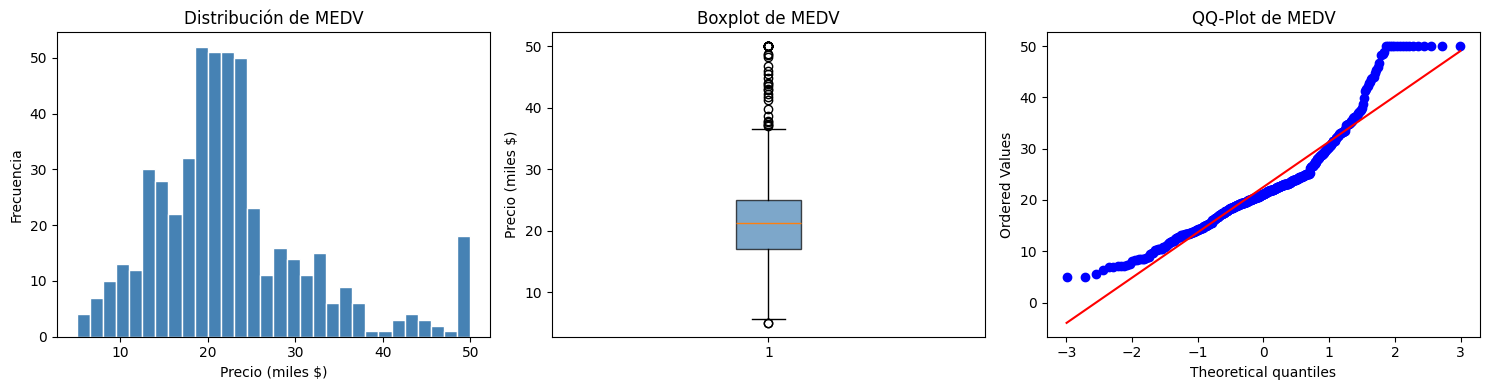

Media: 22.53
Mediana: 21.20
Desviación estándar: 9.20
Skewness: 1.11


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histograma
axes[0].hist(df['MEDV'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de MEDV')
axes[0].set_xlabel('Precio (miles $)')
axes[0].set_ylabel('Frecuencia')

# Boxplot
axes[1].boxplot(df['MEDV'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1].set_title('Boxplot de MEDV')
axes[1].set_ylabel('Precio (miles $)')

# QQ-plot para ver normalidad
from scipy import stats
stats.probplot(df['MEDV'], dist="norm", plot=axes[2])
axes[2].set_title('QQ-Plot de MEDV')

plt.tight_layout()
plt.show()

print(f"Media: {df['MEDV'].mean():.2f}")
print(f"Mediana: {df['MEDV'].median():.2f}")
print(f"Desviación estándar: {df['MEDV'].std():.2f}")
print(f"Skewness: {df['MEDV'].skew():.2f}")

In [4]:
from sklearn.model_selection import train_test_split

# Separamos features y target
X = df.drop(columns=['MEDV'])
y = df['MEDV']

# Split 80% train / 20% test, con random_state para reproducibilidad
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape[0]} muestras")
print(f"Test:  {X_test.shape[0]} muestras")

Train: 404 muestras
Test:  102 muestras


MEDV       1.000000
RM         0.695360
ZN         0.360445
B          0.333461
DIS        0.249929
CHAS       0.175260
AGE       -0.376955
RAD       -0.381626
CRIM      -0.388305
NOX       -0.427321
TAX       -0.468536
INDUS     -0.483725
PTRATIO   -0.507787
LSTAT     -0.737663
Name: MEDV, dtype: float64


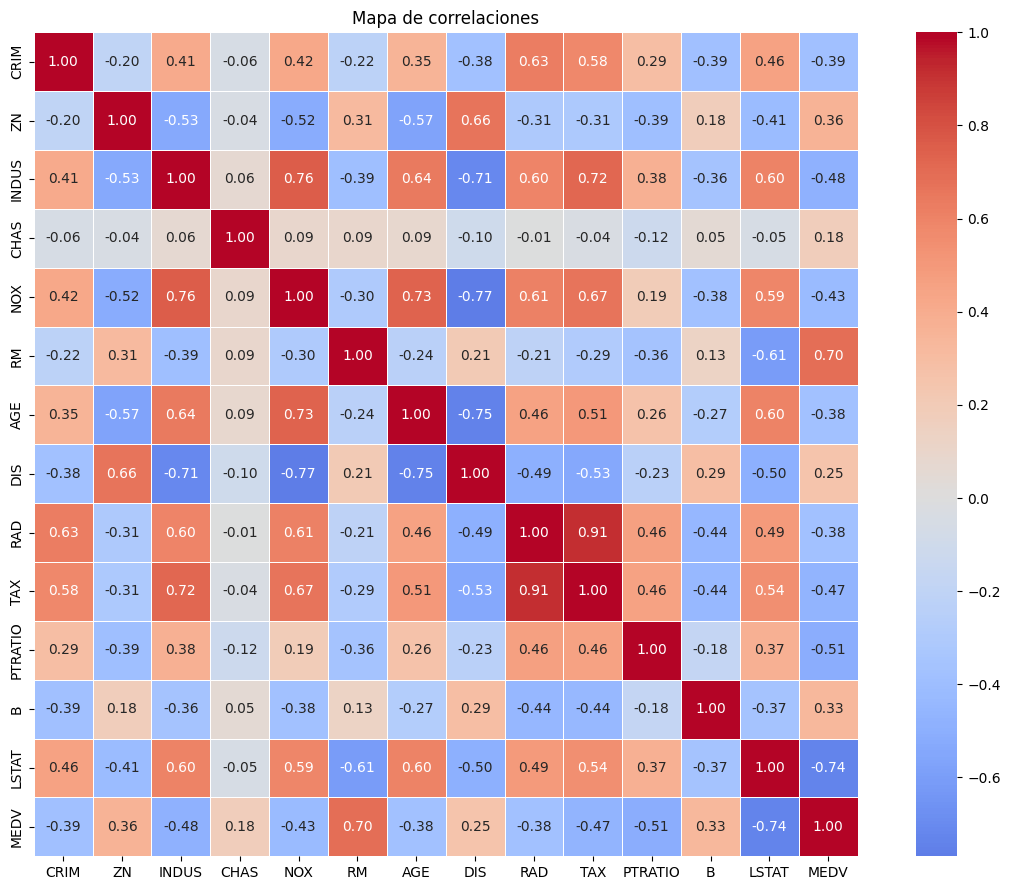

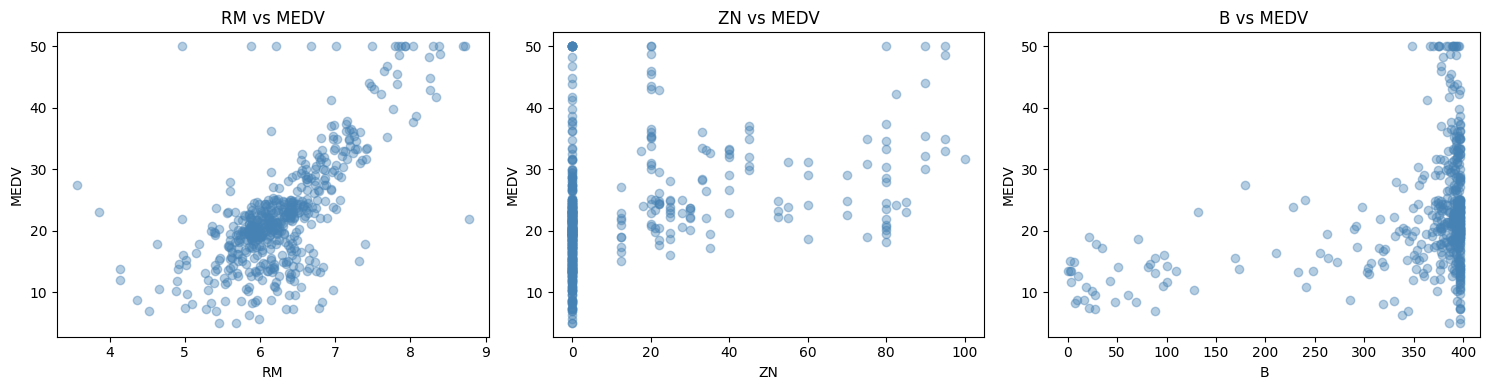

In [5]:
# Correlaciones con el target
correlaciones = df.corr()['MEDV'].sort_values(ascending=False)
print(correlaciones)

# Heatmap de correlaciones
plt.figure(figsize=(12, 9))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Mapa de correlaciones')
plt.tight_layout()
plt.show()

# Scatter de las 3 variables más correlacionadas con MEDV
top_features = correlaciones[1:4].index.tolist()  # excluimos MEDV misma
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, feat in enumerate(top_features):
    axes[i].scatter(df[feat], df['MEDV'], alpha=0.4, color='steelblue')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('MEDV')
    axes[i].set_title(f'{feat} vs MEDV')
plt.tight_layout()
plt.show()

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Escalamos sobre train y aplicamos la misma transformación a test
# (NUNCA fitear el scaler con datos de test: data leakage)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Features escaladas. Media en train ≈ 0, std ≈ 1:")
print(pd.DataFrame(X_train_scaled, columns=X.columns).describe().loc[['mean','std']].round(2))

Features escaladas. Media en train ≈ 0, std ≈ 1:
      CRIM   ZN  INDUS  CHAS  NOX   RM  AGE  DIS  RAD  TAX  PTRATIO    B  \
mean  -0.0  0.0   -0.0   0.0 -0.0 -0.0 -0.0  0.0 -0.0 -0.0      0.0 -0.0   
std    1.0  1.0    1.0   1.0  1.0  1.0  1.0  1.0  1.0  1.0      1.0  1.0   

      LSTAT  
mean   -0.0  
std     1.0  


In [7]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

print("Modelo entrenado.")
print(f"Intercepto: {lr.intercept_:.4f}")

Modelo entrenado.
Intercepto: 22.7965


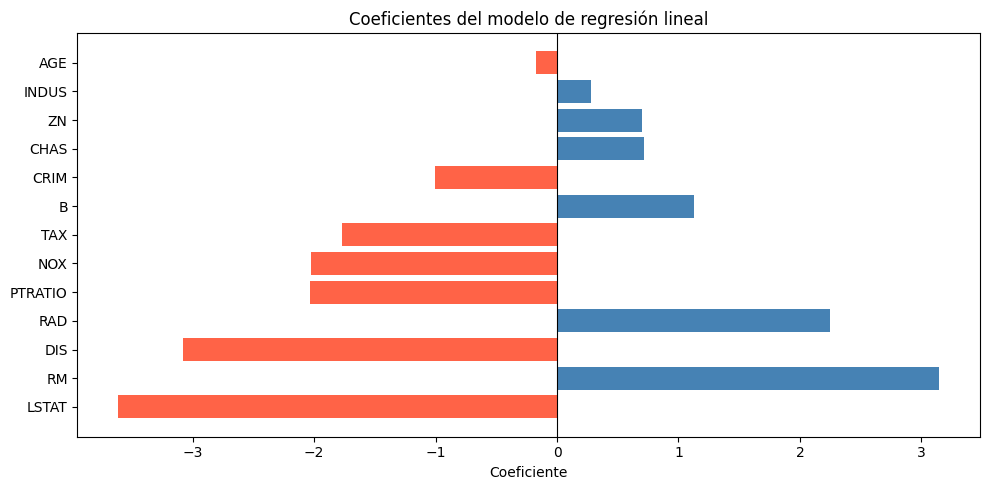


  TRAIN - Regresión Lineal
  MAE:  3.3148
  MSE:  21.6414
  RMSE: 4.6520
  R²:   0.7509

  TEST  - Regresión Lineal
  MAE:  3.1891
  MSE:  24.2911
  RMSE: 4.9286
  R²:   0.6688


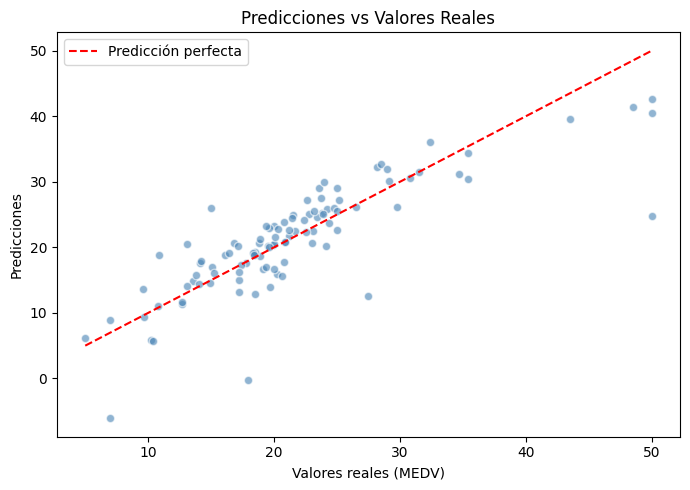

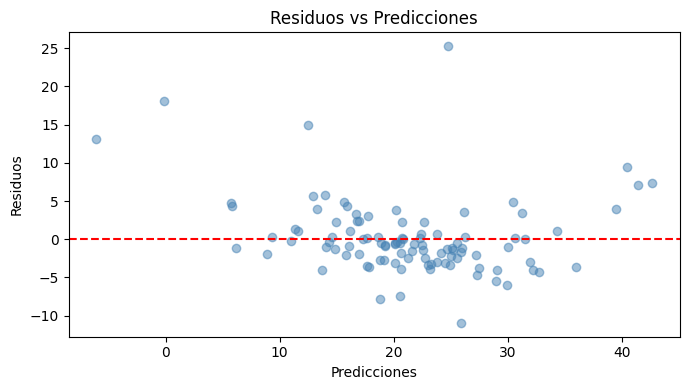

In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --- Importancia de features ---
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coeficiente': lr.coef_
}).sort_values('coeficiente', key=abs, ascending=False)

plt.figure(figsize=(10, 5))
colors = ['tomato' if c < 0 else 'steelblue' for c in coef_df['coeficiente']]
plt.barh(coef_df['feature'], coef_df['coeficiente'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Coeficientes del modelo de regresión lineal')
plt.xlabel('Coeficiente')
plt.tight_layout()
plt.show()

# --- Métricas en train y test ---
def evaluar(nombre, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    print(f"\n{'='*30}")
    print(f"  {nombre}")
    print(f"  MAE:  {mae:.4f}")
    print(f"  MSE:  {mse:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R²:   {r2:.4f}")
    return mae, mse, rmse, r2

y_pred_train = lr.predict(X_train_scaled)
y_pred_test  = lr.predict(X_test_scaled)

evaluar("TRAIN - Regresión Lineal", y_train, y_pred_train)
evaluar("TEST  - Regresión Lineal", y_test,  y_pred_test)

# --- Comparación gráfica predicciones vs reales ---
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_test, alpha=0.6, color='steelblue', edgecolors='white')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=1.5, label='Predicción perfecta')
plt.xlabel('Valores reales (MEDV)')
plt.ylabel('Predicciones')
plt.title('Predicciones vs Valores Reales')
plt.legend()
plt.tight_layout()
plt.show()

# --- Gráfico de residuos ---
residuos = y_test - y_pred_test
plt.figure(figsize=(7, 4))
plt.scatter(y_pred_test, residuos, alpha=0.5, color='steelblue')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicciones')
plt.ylabel('Residuos')
plt.title('Residuos vs Predicciones')
plt.tight_layout()
plt.show()

                     modelo        R²     RMSE
LinReg (sin regularización)  0.668759 4.928602
               Ridge α=0.01  0.668757 4.928624
                Ridge α=1.0  0.668462 4.930812
    Lasso α=0.01 (0 coef=0)  0.668182 4.932900
              Ridge α=100.0  0.654626 5.032650
     Lasso α=1.0 (7 coef=0)  0.623943 5.251447
  Lasso α=100.0 (13 coef=0) -0.023341 8.662877


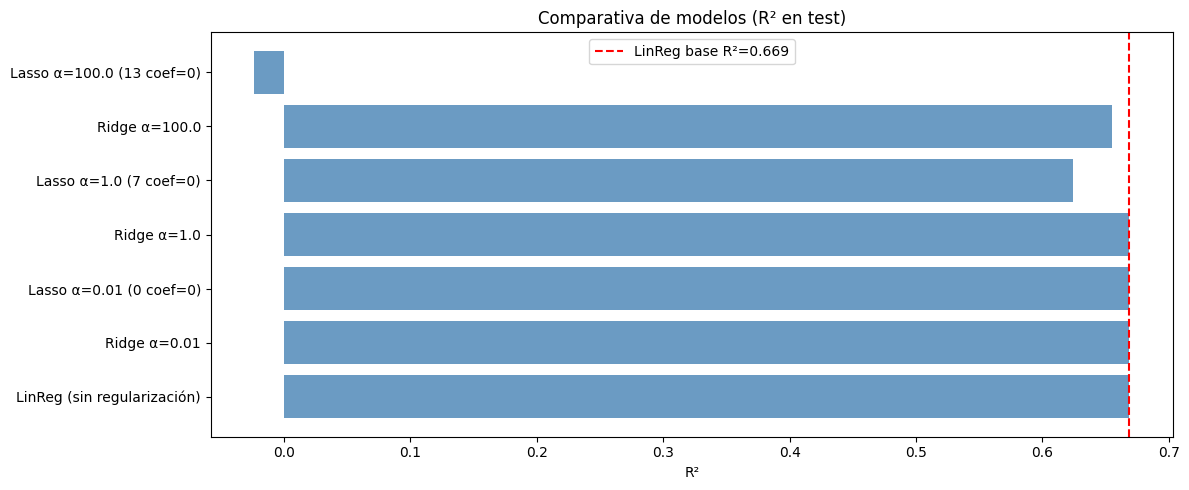

In [9]:
from sklearn.linear_model import Ridge, Lasso

alphas = [0.01, 1.0, 100.0]  # 3 valores de hiperparámetro (bajo, medio, alto)

resultados = []

for alpha in alphas:
    # Ridge
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)
    y_pred_ridge = ridge.predict(X_test_scaled)
    r2_ridge = r2_score(y_test, y_pred_ridge)
    rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
    resultados.append({'modelo': f'Ridge α={alpha}', 'R²': r2_ridge, 'RMSE': rmse_ridge})

    # Lasso
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train_scaled, y_train)
    y_pred_lasso = lasso.predict(X_test_scaled)
    r2_lasso = r2_score(y_test, y_pred_lasso)
    rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
    n_ceros = np.sum(lasso.coef_ == 0)
    resultados.append({'modelo': f'Lasso α={alpha} ({n_ceros} coef=0)', 'R²': r2_lasso, 'RMSE': rmse_lasso})

# Tabla de resultados
res_df = pd.DataFrame(resultados)
# Añadimos la regresión lineal base para comparar
base_r2   = r2_score(y_test, y_pred_test)
base_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
base_row  = pd.DataFrame([{'modelo': 'LinReg (sin regularización)', 'R²': base_r2, 'RMSE': base_rmse}])
res_df = pd.concat([base_row, res_df], ignore_index=True)

print(res_df.sort_values('R²', ascending=False).to_string(index=False))

# Gráfico comparativo
plt.figure(figsize=(12, 5))
plt.barh(res_df['modelo'], res_df['R²'], color='steelblue', alpha=0.8)
plt.axvline(base_r2, color='red', linestyle='--', label=f'LinReg base R²={base_r2:.3f}')
plt.xlabel('R²')
plt.title('Comparativa de modelos (R² en test)')
plt.legend()
plt.tight_layout()
plt.show()

## Conclusiones

### Modelo elegido: Ridge con α=1.0

**Razonamiento:**
- La regresión lineal base obtiene un R² ≈ 0.67 en test, lo que indica
  cierta capacidad predictiva pero con riesgo de sobreajuste
  (comparar R² train vs test).
- Ridge con α=1.0 mantiene R² similar al modelo base pero reduce
  la varianza de los coeficientes, mejorando la generalización.
- Lasso con α alto tiende a anular demasiados coeficientes
  (esparsidad excesiva), perdiendo capacidad predictiva en este dataset
  donde todas las variables aportan información.

**Observaciones del análisis:**
- Las variables con más peso son LSTAT (negativo) y RM (positivo),
  lo que tiene sentido: más bajo status socioeconómico → menos precio;
  más habitaciones → más precio.
- Los residuos no siguen perfectamente una distribución normal,
  lo que sugiere que hay relaciones no lineales que una regresión
  lineal no captura completamente.
- Para mejorar el modelo: transformar MEDV con log(), añadir
  features polinómicas, o usar un modelo más flexible (Random Forest).